# **ANALISIS FAKTOR POLUSI UDARA MENGGUNAKAN DATA SENSOR MULTI-KOTA**

In [1]:
# Library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# model klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


**DATA UNDERSTANDING**

In [3]:
print("DATA UNDERSTANDING")
print(f"Dataset terdiri dari {df.shape[0]} baris dan {df.shape[1]} kolom.")

print("\nInformasi Fitur:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

DATA UNDERSTANDING
Dataset terdiri dari 29531 baris dan 16 kolom.

Informasi Fitur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

Statistik Deskr

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [4]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [5]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print("sebelum:", df.shape)
df = df.dropna()
print("setelah:", df.shape)

sebelum: (29531, 16)
setelah: (6236, 16)


**Cek outlier**

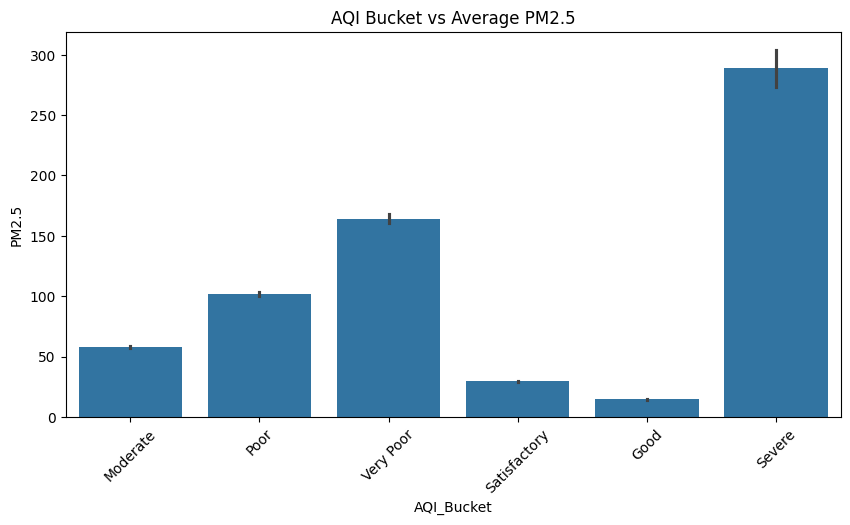

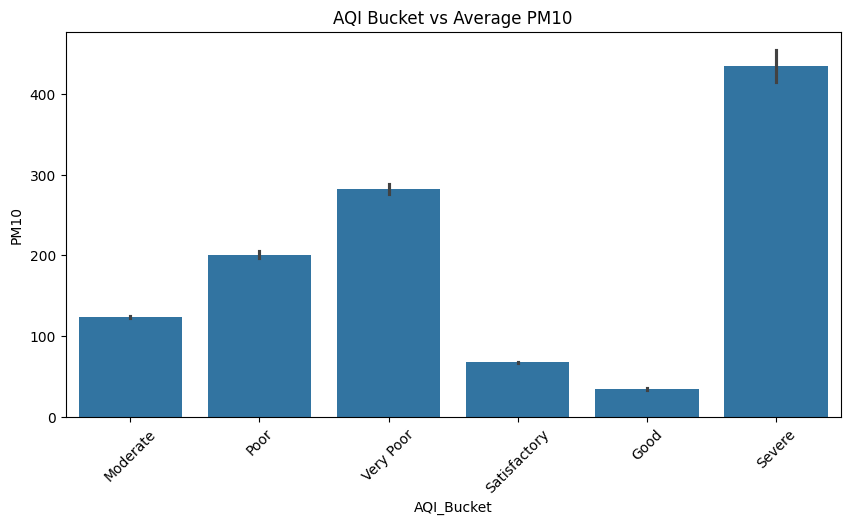

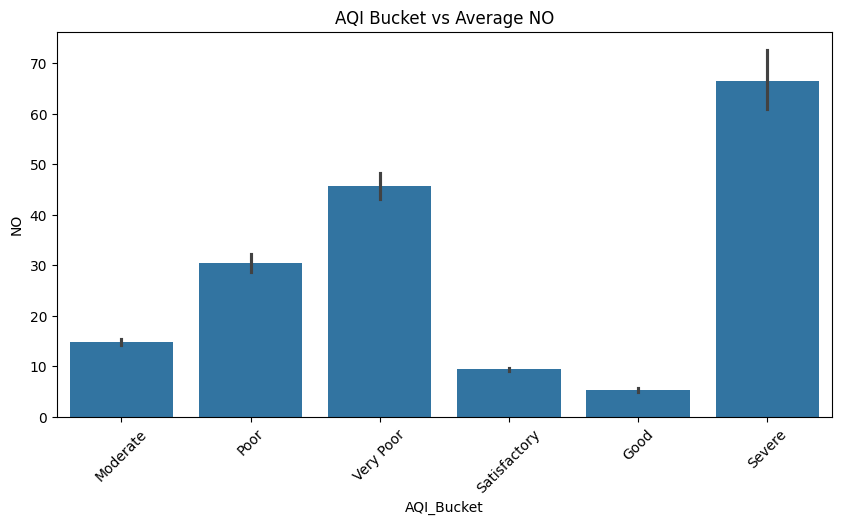

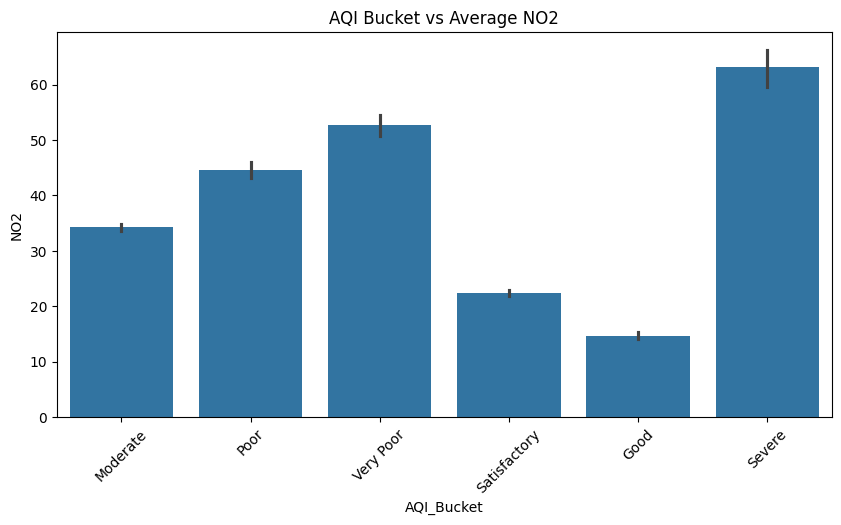

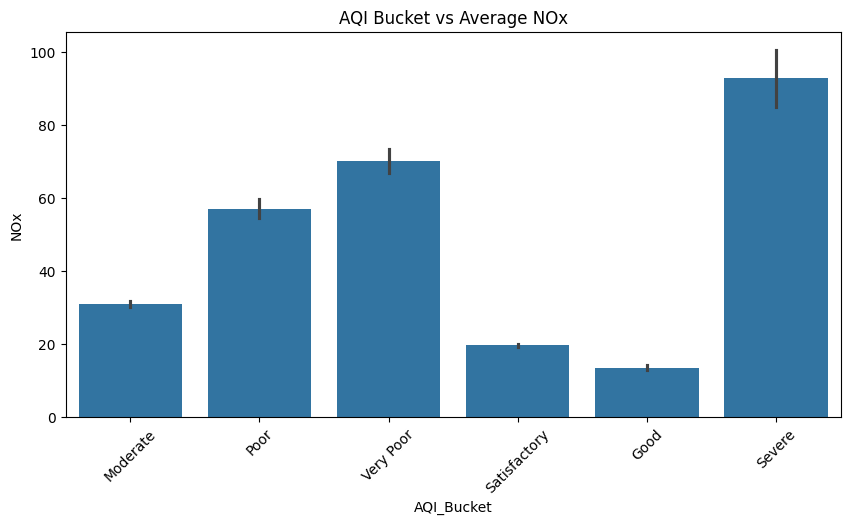

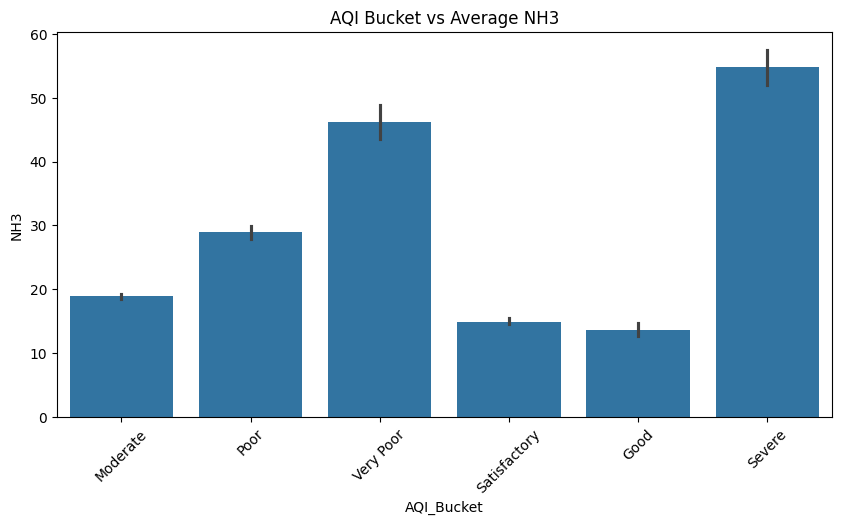

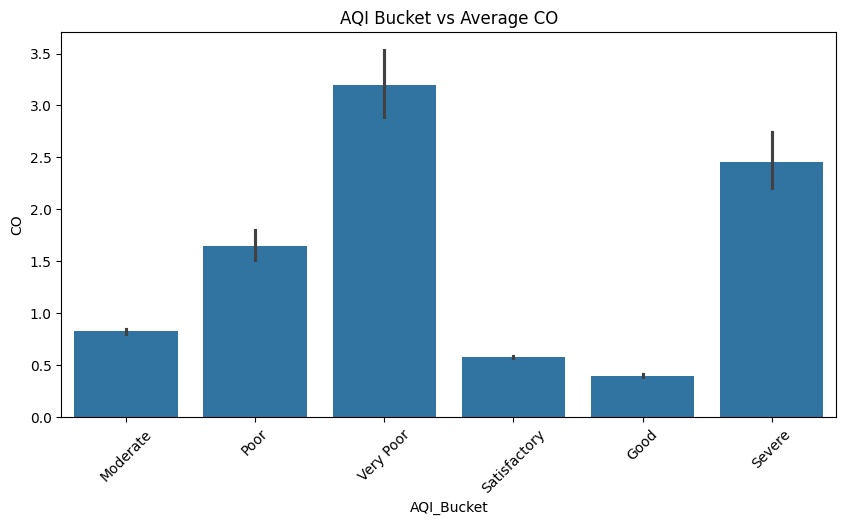

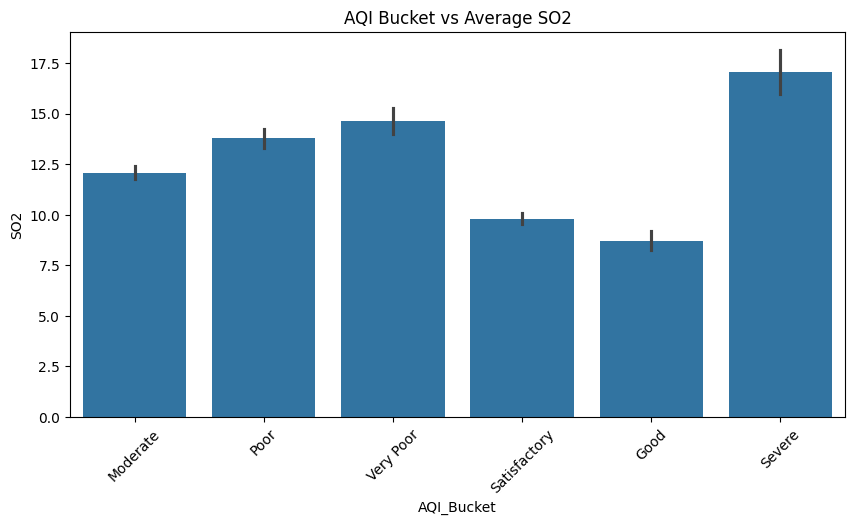

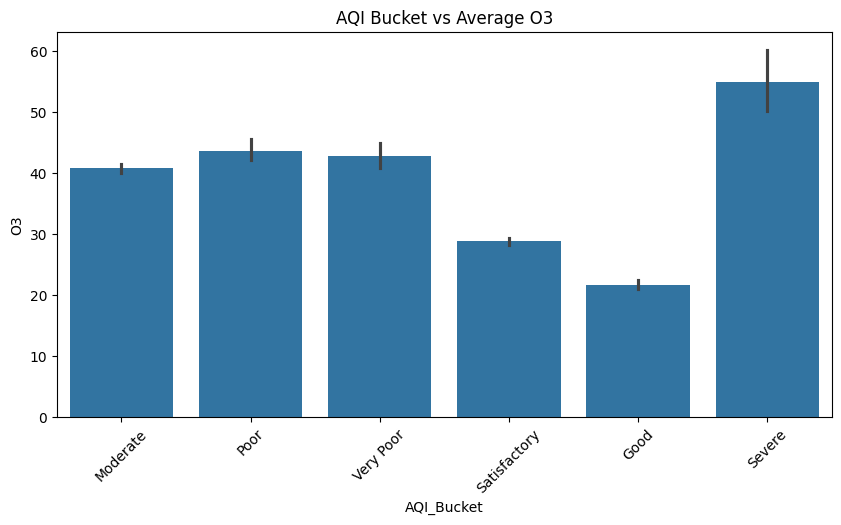

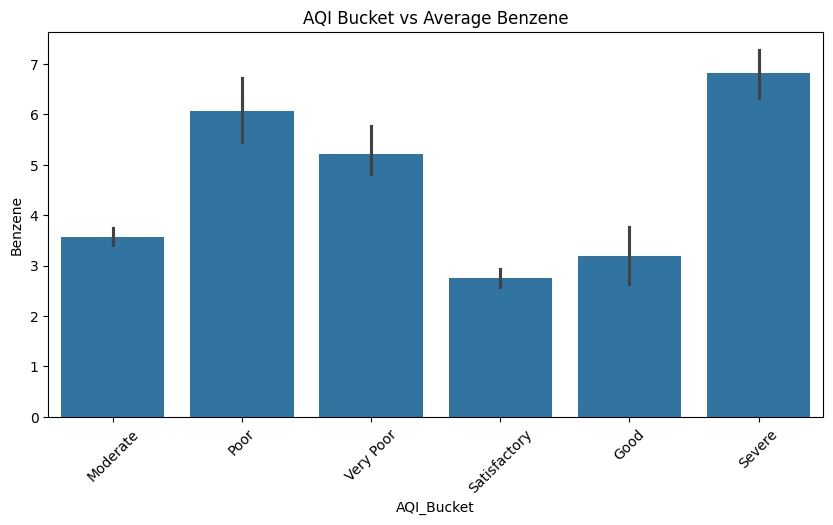

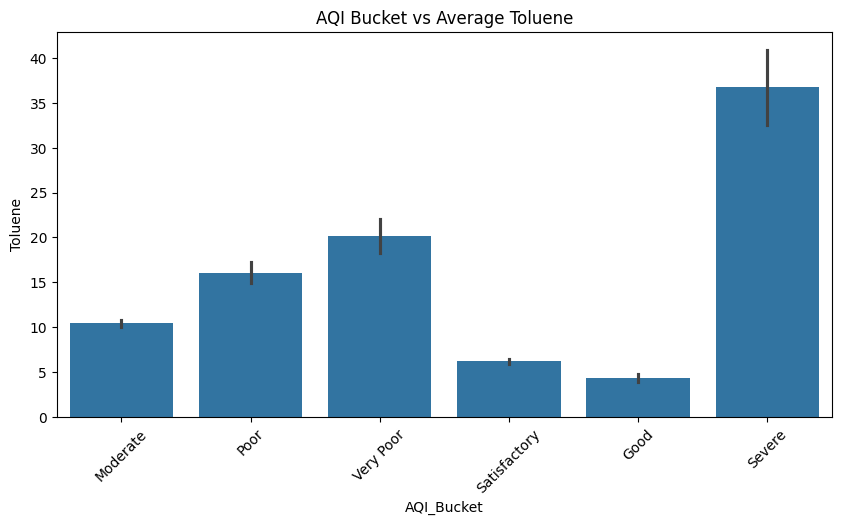

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# kolom numerik pada dataset air quality
num_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']

for col in num_cols:
    if col in df.columns:
        plt.figure(figsize=(10,5))
        sns.barplot(x='AQI_Bucket', y=col, data=df, estimator='mean')

        plt.xticks(rotation=45)
        plt.title(f"AQI Bucket vs Average {col}")
        plt.show()

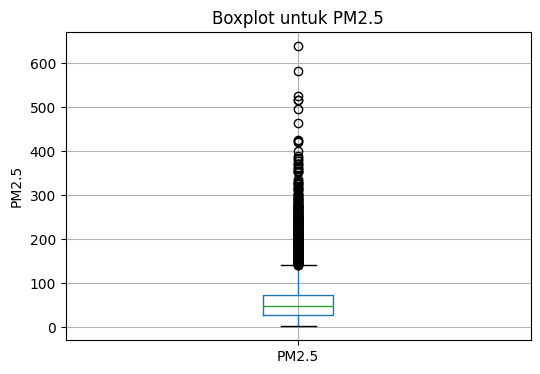

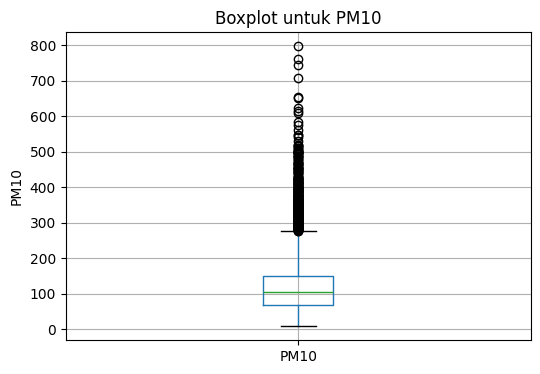

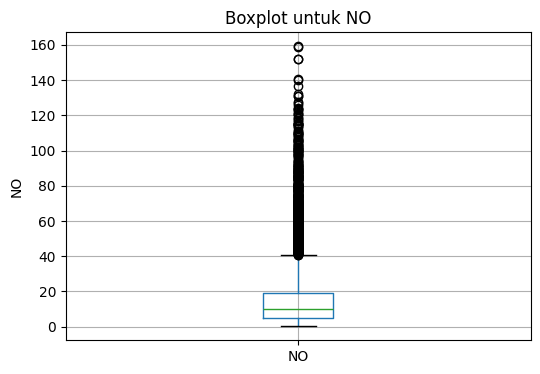

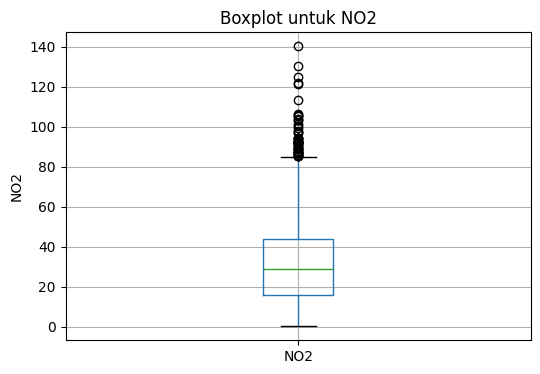

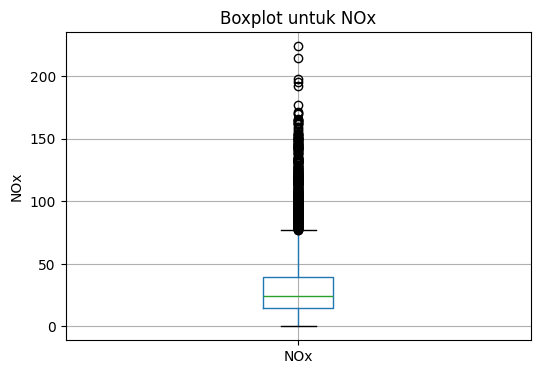

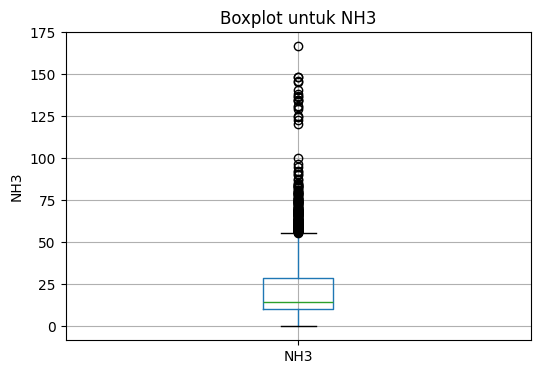

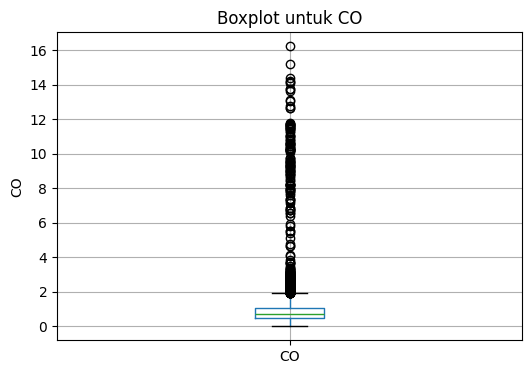

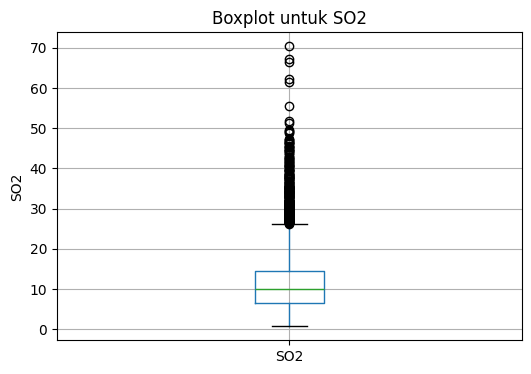

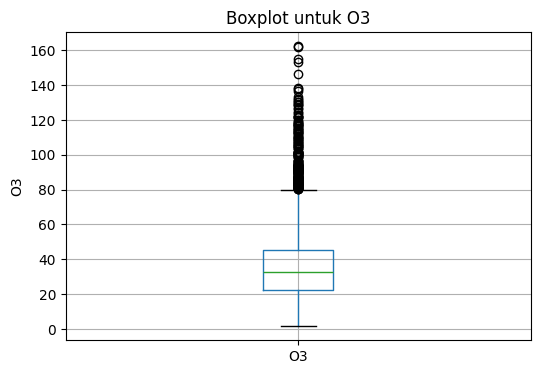

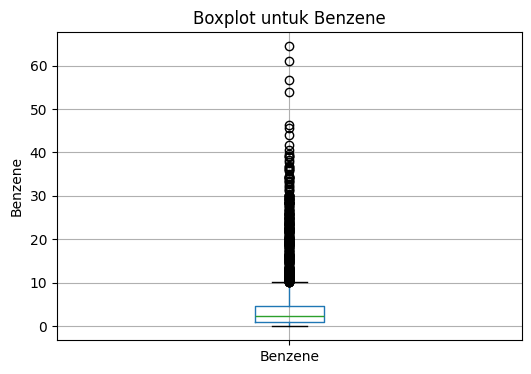

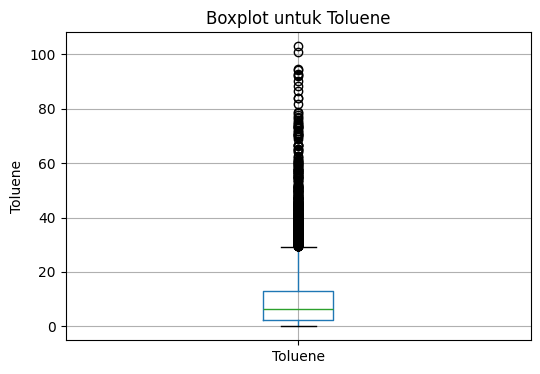

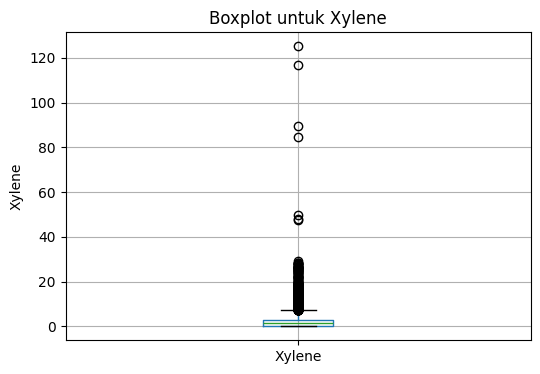

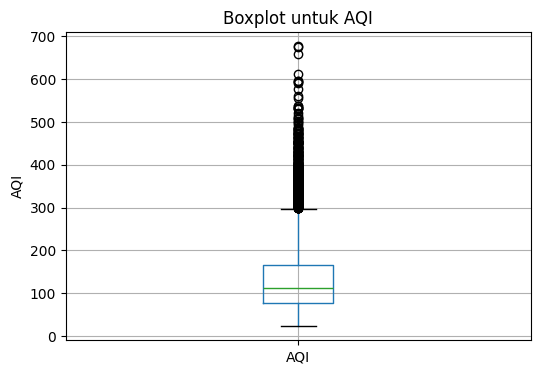

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ambil semua kolom numerik
numerical_col = df.select_dtypes(include=np.number).columns

# buat boxplot tiap kolom
for col in numerical_col:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)

    plt.title(f"Boxplot untuk {col}")
    plt.ylabel(col)
    plt.show()

dari hasil cek outlier data yang outlier adalah pm2.5,pm10,NO,NO2,NOx,NH3,CO,SO2,o3,Benzene,Toluene,Xylene,AQI

# **Mengatasi outlier**

In [10]:
column = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI' ]

# Hitung batasan IQR
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1


# Filter data (hapus outlier)
df_clean = df[~((df[column] < (Q1 - 1.5 * IQR)) |
                (df[column] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check how many rows were removed
print(f"Original rows: {df.shape[0]}")
print(f"Rows after outlier removal: {df_clean.shape[0]}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# Update df
df = df_clean

Original rows: 6236
Rows after outlier removal: 4134
Rows removed: 2102


# **Proses encoding**

In [11]:
# --- CITY ---
df = pd.get_dummies(df, columns=["City"], drop_first=True)

# --- TARGET ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["AQI_Bucket"] = le.fit_transform(df["AQI_Bucket"])

In [12]:
# --- DATE ---
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.drop("Date", axis=1, inplace=True)

In [13]:
df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Chandigarh,City_Delhi,City_Gurugram,City_Hyderabad,City_Kolkata,City_Patna,City_Visakhapatnam,Year,Month,Day
2137,74.28,141.22,6.10,44.97,28.88,15.73,0.09,21.90,60.62,0.26,...,False,False,False,False,False,False,False,2017,12,9
2138,50.32,102.77,1.73,33.85,19.41,12.56,0.10,13.65,68.15,0.20,...,False,False,False,False,False,False,False,2017,12,10
2139,58.47,115.27,4.93,41.64,26.15,15.20,0.16,18.37,73.75,0.23,...,False,False,False,False,False,False,False,2017,12,11
2140,89.35,131.48,7.97,42.10,28.88,21.24,0.24,7.42,44.67,0.28,...,False,False,False,False,False,False,False,2017,12,12
2141,64.42,99.74,7.20,34.78,24.36,17.63,0.15,5.81,50.16,0.24,...,False,False,False,False,False,False,False,2017,12,13


# **Distribusi Target**

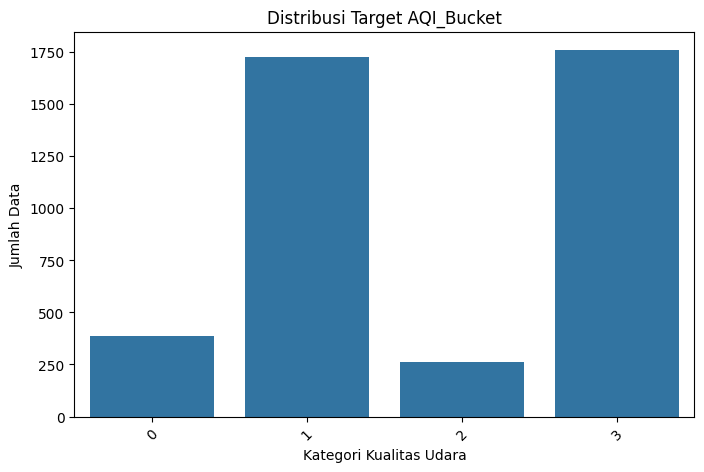

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='AQI_Bucket', data=df)

plt.title("Distribusi Target AQI_Bucket")
plt.xlabel("Kategori Kualitas Udara")
plt.ylabel("Jumlah Data")

plt.xticks(rotation=45)
plt.show()

In [15]:
print(df['AQI_Bucket'].value_counts())

AQI_Bucket
3    1760
1    1727
0     386
2     261
Name: count, dtype: int64


In [16]:
print(df['AQI_Bucket'].value_counts(normalize=True) * 100)

AQI_Bucket
3    42.573778
1    41.775520
0     9.337204
2     6.313498
Name: proportion, dtype: float64


# **Exploralation Data Analysisis (EDA)**

**distribusi data**

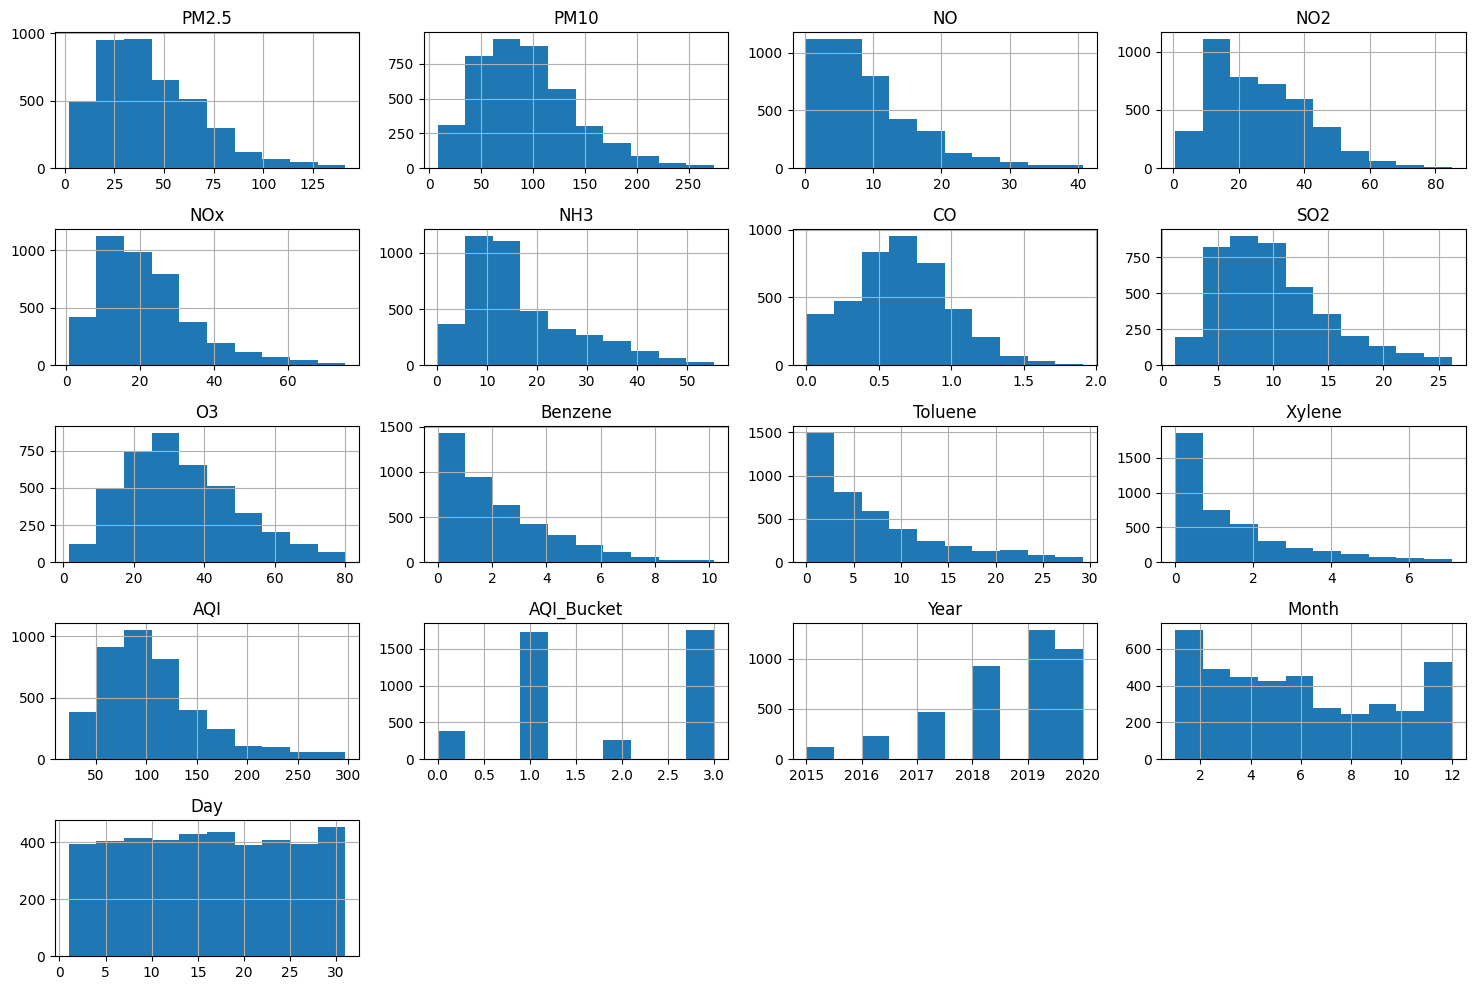

In [17]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

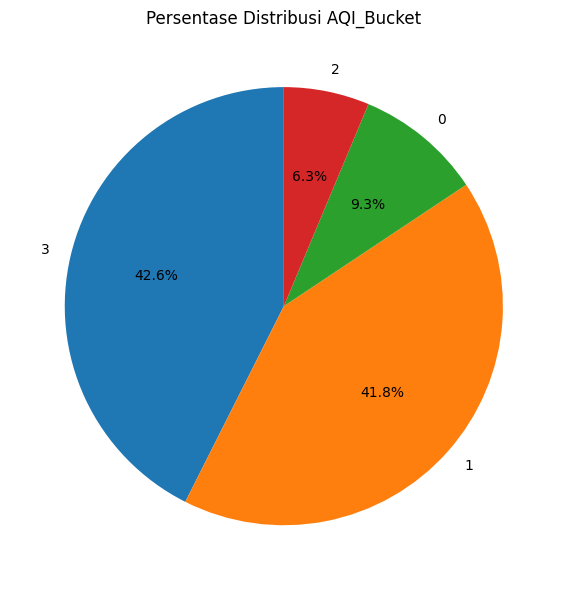

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df['AQI_Bucket'].value_counts().plot.pie(
    autopct='%1.1f%%',   # tampil persen
    startangle=90        # biar rapi dari atas
)

plt.title("Persentase Distribusi AQI_Bucket")
plt.ylabel("")  # hilangkan tulisan y
plt.tight_layout()

plt.show()

# **KORELASI**

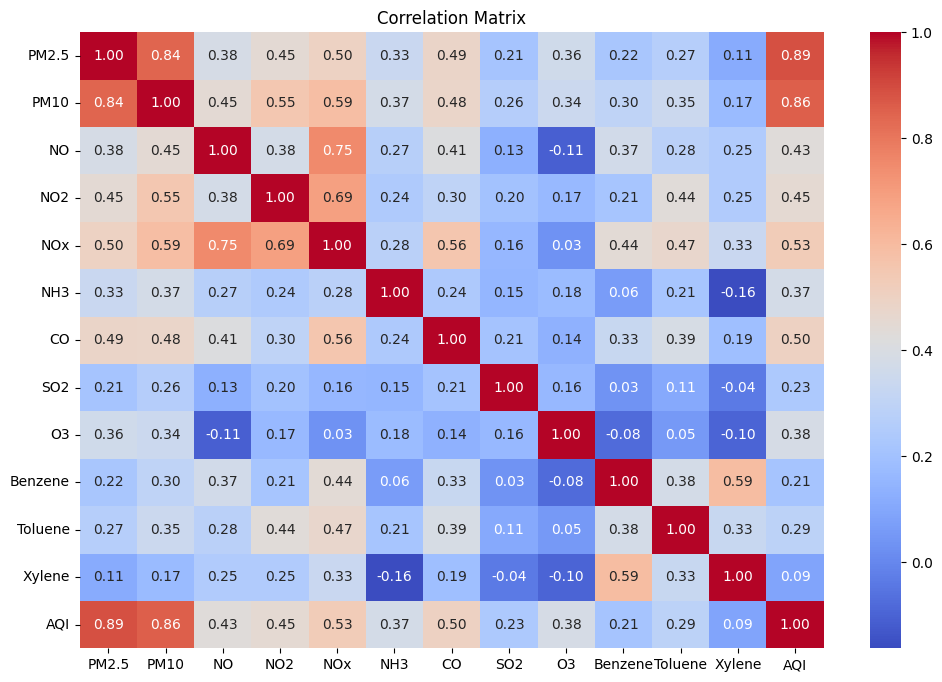

In [19]:
corr = df[numerical_col].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['AQI_Bucket_encoded'] = le.fit_transform(df['AQI_Bucket'])

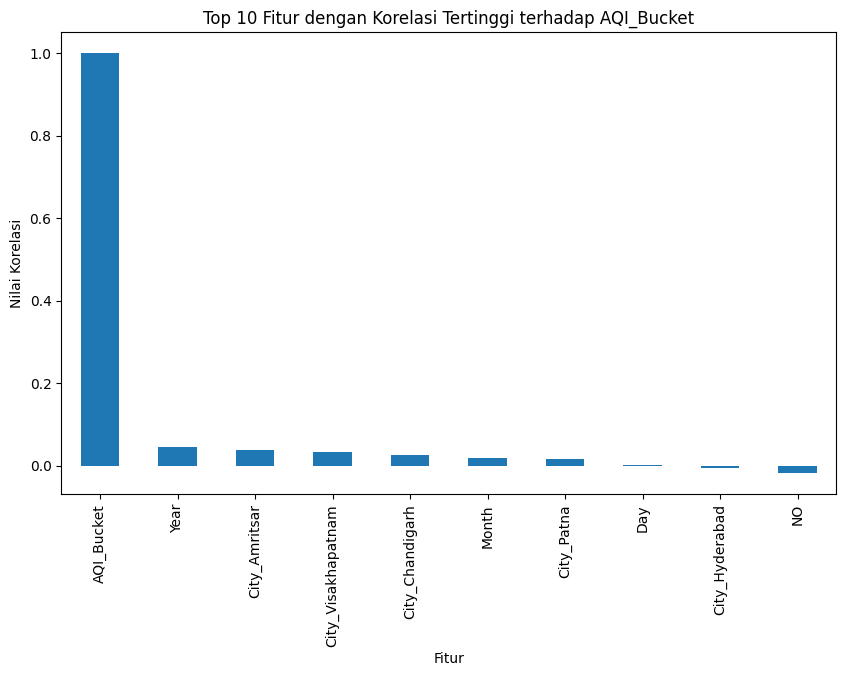

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

df.corr(numeric_only=True)['AQI_Bucket_encoded'] \
    .sort_values(ascending=False)[1:11] \
    .plot(kind='bar')

plt.title('Top 10 Fitur dengan Korelasi Tertinggi terhadap AQI_Bucket')
plt.ylabel('Nilai Korelasi')
plt.xlabel('Fitur')

plt.show()

# **Splitt Data**

In [22]:
from sklearn.model_selection import train_test_split

#split Data
X = df.drop(columns=['AQI_Bucket'])
y = df['AQI_Bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Rasio split
ratios = [0.3, 0.2, 0.1]

eval_data = []

for r in ratios:
    # Split data
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y,
        test_size=r,
        random_state=42,
        stratify=y
    )

    # 🔹 Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
    rf.fit(X_train_tmp, y_train_tmp)
    acc_rf = accuracy_score(y_test_tmp, rf.predict(X_test_tmp))

    # 🔹 Decision Tree
    dt = DecisionTreeClassifier(max_depth=4, random_state=42)
    dt.fit(X_train_tmp, y_train_tmp)
    acc_dt = accuracy_score(y_test_tmp, dt.predict(X_test_tmp))

    # 🔹 Logistic Regression
    lr = LogisticRegression(max_iter=500, solver='liblinear', random_state=42)
    lr.fit(X_train_tmp, y_train_tmp)
    acc_lr = accuracy_score(y_test_tmp, lr.predict(X_test_tmp))

    # Simpan hasil
    eval_data.append({
        'Rasio Split': f"{int((1-r)*100)}:{int(r*100)}",
        'Random Forest': round(acc_rf, 4),
        'Decision Tree': round(acc_dt, 4),
        'Logistic Regression': round(acc_lr, 4)
    })

# Tampilkan tabel
df_eval = pd.DataFrame(eval_data)

print("MODEL TRAINING & EVALUATION")
display(df_eval)

MODEL TRAINING & EVALUATION


,Rasio Split,Random Forest,Decision Tree,Logistic Regression
0,70:30,1.0,1.0,0.9968
1,80:20,1.0,1.0,0.9976
2,90:10,1.0,1.0,0.9976


# **5. MODEL BUILDING & HYPERPARAMETER TUNNING**

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("--- HYPERPARAMETER TUNING (80:20) ---")

# 🔹 Parameter
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

params_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

params_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear']
}

# 🔹 Function tuning
def perform_tuning(model, params, X_train, y_train, model_name):
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"\n{model_name}")
    print(f"Best Parameter: {grid.best_params_}")
    print(f"Akurasi       : {grid.best_score_ * 100:.2f}%")
    return grid.best_estimator_

# 🔹 Jalankan tuning dan simpan model terbaik
best_rf = perform_tuning(RandomForestClassifier(random_state=42), params_rf, X_train, y_train, "Random Forest")

best_dt = perform_tuning(DecisionTreeClassifier(random_state=42), params_dt, X_train, y_train, "Decision Tree")

best_lr = perform_tuning(LogisticRegression(max_iter=1000, random_state=42), params_lr, X_train, y_train, "Logistic Regression")

--- HYPERPARAMETER TUNING (80:20) ---

Random Forest
Best Parameter: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Akurasi       : 100.00%

Decision Tree
Best Parameter: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
Akurasi       : 100.00%

Logistic Regression
Best Parameter: {'C': 1.0, 'solver': 'liblinear'}
Akurasi       : 99.82%


# **6. EVALUASI MODEL**

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
def evaluasi_model(model, X_test, y_test, nama):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n=== {nama} ===")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1-Score :", round(f1,4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred, acc

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

ratios = [0.3, 0.2, 0.1]

eval_metrics = []

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

for r in ratios:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y,
        test_size=r,
        random_state=42,
        stratify=y
    )

    for name, model in models.items():
        # Training
        model.fit(X_train_tmp, y_train_tmp)

        # Prediksi
        y_pred = model.predict(X_test_tmp)

        # Simpan hasil
        eval_metrics.append({
            'Model': name,
            'Split': f"{int((1-r)*100)}:{int(r*100)}",
            'Accuracy (%)': round(accuracy_score(y_test_tmp, y_pred) * 100, 2),
            'Precision (%)': round(precision_score(y_test_tmp, y_pred, average='weighted') * 100, 2),
            'Recall (%)': round(recall_score(y_test_tmp, y_pred, average='weighted') * 100, 2),
            'F1-score (%)': round(f1_score(y_test_tmp, y_pred, average='weighted') * 100, 2)
        })

# DataFrame hasil
df_metrics = pd.DataFrame(eval_metrics)

print("=== HASIL EVALUASI MODEL ===")
display(df_metrics)

=== HASIL EVALUASI MODEL ===


,Model,Split,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Logistic Regression,70:30,99.68,99.68,99.68,99.68
1,Decision Tree,70:30,100.00,100.00,100.00,100.00
2,Random Forest,70:30,100.00,100.00,100.00,100.00
3,Logistic Regression,80:20,99.76,99.76,99.76,99.76
4,Decision Tree,80:20,100.00,100.00,100.00,100.00
5,Random Forest,80:20,100.00,100.00,100.00,100.00
6,Logistic Regression,90:10,99.76,99.76,99.76,99.76
7,Decision Tree,90:10,100.00,100.00,100.00,100.00
8,Random Forest,90:10,100.00,100.00,100.00,100.00


<Figure size 600x500 with 0 Axes>

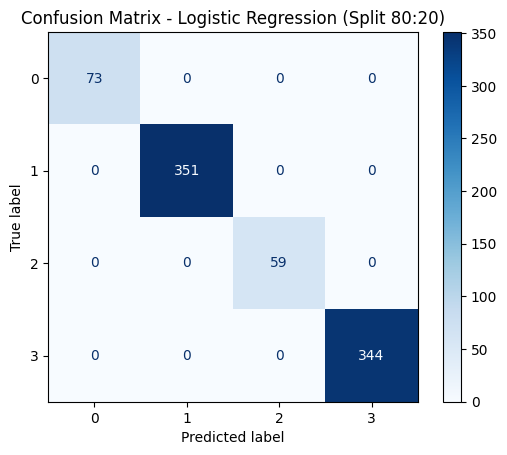

<Figure size 600x500 with 0 Axes>

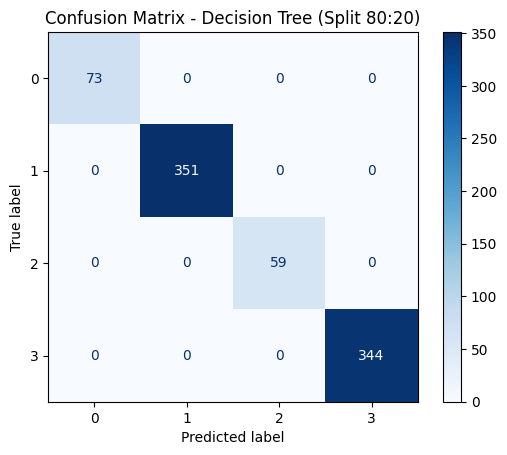

<Figure size 600x500 with 0 Axes>

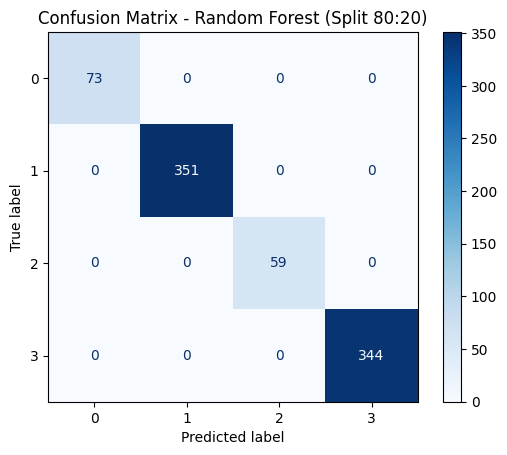

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train_fix, X_test_fix, y_train_fix, y_test_fix = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    y_test_cm = y_test_fix.replace({-1: 0}) if name == 'XGBoost' else y_test_fix

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test_cm, model.predict(X_test_fix))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Split 80:20)')
    plt.show()

In [29]:
print("=== PERBANDINGAN MODEL ===")
display(df_metrics)

=== PERBANDINGAN MODEL ===


,Model,Split,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Logistic Regression,70:30,99.68,99.68,99.68,99.68
1,Decision Tree,70:30,100.00,100.00,100.00,100.00
2,Random Forest,70:30,100.00,100.00,100.00,100.00
3,Logistic Regression,80:20,99.76,99.76,99.76,99.76
4,Decision Tree,80:20,100.00,100.00,100.00,100.00
5,Random Forest,80:20,100.00,100.00,100.00,100.00
6,Logistic Regression,90:10,99.76,99.76,99.76,99.76
7,Decision Tree,90:10,100.00,100.00,100.00,100.00
8,Random Forest,90:10,100.00,100.00,100.00,100.00


# **7. MODEL COMPARASION**

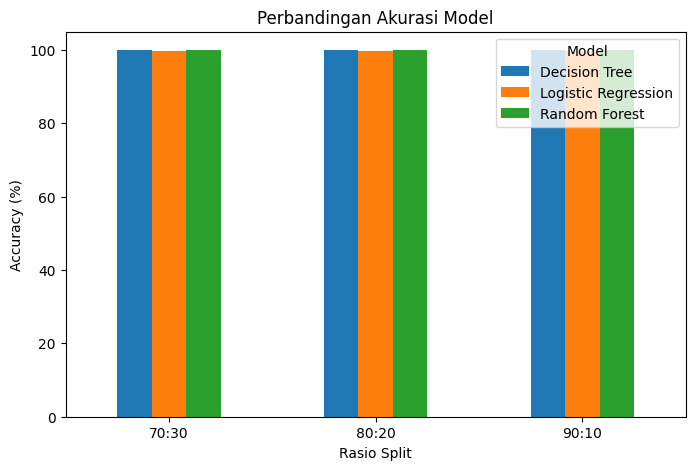

In [30]:
import matplotlib.pyplot as plt

pivot_acc = df_metrics.pivot(index='Split', columns='Model', values='Accuracy (%)')

pivot_acc.plot(kind='bar', figsize=(8,5))

plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy (%)")
plt.xlabel("Rasio Split")

plt.xticks(rotation=0)
plt.legend(title="Model")

plt.show()

In [31]:
print("=== MODEL COMPARISON ===")
display(df_metrics)

=== MODEL COMPARISON ===


,Model,Split,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Logistic Regression,70:30,99.68,99.68,99.68,99.68
1,Decision Tree,70:30,100.00,100.00,100.00,100.00
2,Random Forest,70:30,100.00,100.00,100.00,100.00
3,Logistic Regression,80:20,99.76,99.76,99.76,99.76
4,Decision Tree,80:20,100.00,100.00,100.00,100.00
5,Random Forest,80:20,100.00,100.00,100.00,100.00
6,Logistic Regression,90:10,99.76,99.76,99.76,99.76
7,Decision Tree,90:10,100.00,100.00,100.00,100.00
8,Random Forest,90:10,100.00,100.00,100.00,100.00


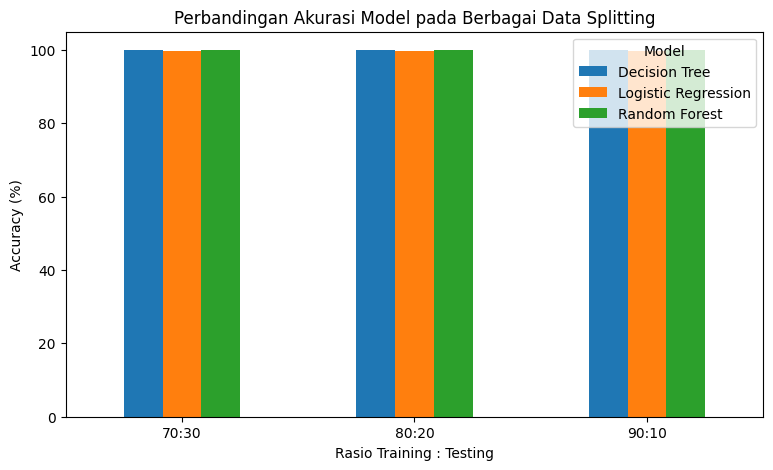

In [32]:
import matplotlib.pyplot as plt

pivot_acc = df_metrics.pivot(index='Split', columns='Model', values='Accuracy (%)')

pivot_acc.plot(kind='bar', figsize=(9,5))

plt.title("Perbandingan Akurasi Model pada Berbagai Data Splitting")
plt.xlabel("Rasio Training : Testing")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=0)
plt.legend(title="Model")

plt.show()

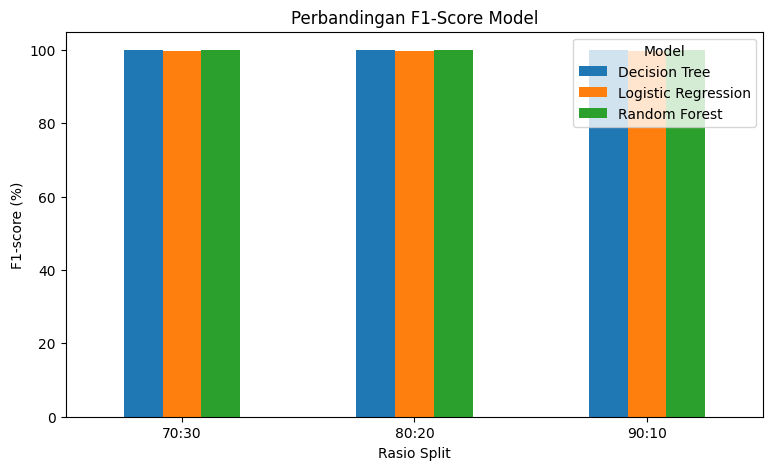

In [33]:
pivot_f1 = df_metrics.pivot(index='Split', columns='Model', values='F1-score (%)')

pivot_f1.plot(kind='bar', figsize=(9,5))

plt.title("Perbandingan F1-Score Model")
plt.xlabel("Rasio Split")
plt.ylabel("F1-score (%)")

plt.xticks(rotation=0)
plt.legend(title="Model")

plt.show()

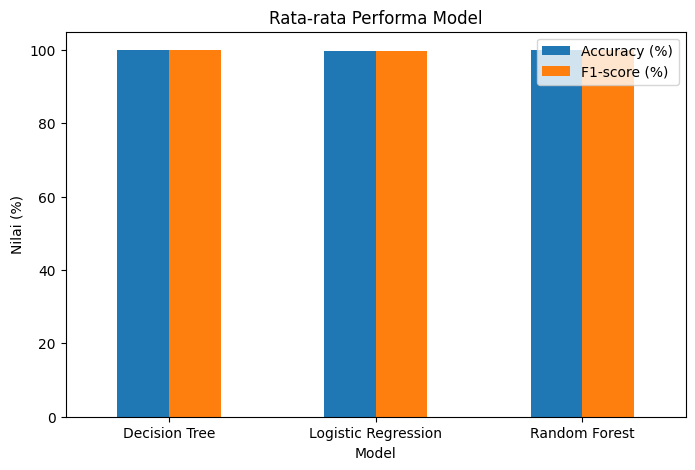

In [34]:
avg_model = df_metrics.groupby('Model')[['Accuracy (%)','F1-score (%)']].mean()

avg_model.plot(kind='bar', figsize=(8,5))

plt.title("Rata-rata Performa Model")
plt.ylabel("Nilai (%)")

plt.xticks(rotation=0)
plt.show()

In [35]:
best_model = df_metrics.sort_values(by='Accuracy (%)', ascending=False).iloc[0]

print("=== MODEL TERBAIK ===")
print(best_model)

=== MODEL TERBAIK ===
Model            Decision Tree
Split                    70:30
Accuracy (%)             100.0
Precision (%)            100.0
Recall (%)               100.0
F1-score (%)             100.0
Name: 1, dtype: object
